# Find chessboard using OpenCV's detect chessboard

In [54]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math
import os

Convert the image to grayscale because we are only interrested in the difference between dark and bright colors. Apply blur filter to remove the details of the chess pieces.

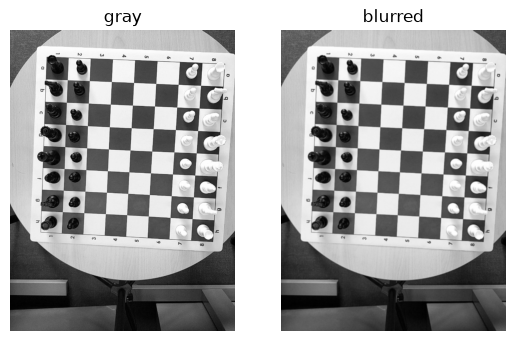

In [55]:
image = cv2.imread('../samples/screenshot.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.subplot(1, 2, 1)
plt.title("gray")
plt.imshow(gray, cmap='gray')
plt.axis('off')

blurred = cv2.GaussianBlur(gray, (3, 3), 0)

plt.subplot(1, 2, 2)
plt.title("blurred")
plt.imshow(blurred, cmap='gray')
plt.axis('off')
plt.show()



Detect chessboard using OpenCV's findChessboardCorners detection algoritm.

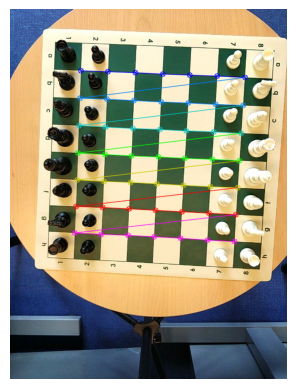

In [56]:
BOARD_SIZE = (7, 7)

ok, corners = cv2.findChessboardCornersSB(
    gray,
    BOARD_SIZE,
    flags=cv2.CALIB_CB_NORMALIZE_IMAGE | cv2.CALIB_CB_EXHAUSTIVE,
)

if ok:
    corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), 
                                   criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001))
image_with_corners = image.copy()
cv2.drawChessboardCorners(image_with_corners, BOARD_SIZE, corners2, ok)
plt.imshow(image_with_corners)
plt.axis('off')
plt.show()

Calculate the bounding box of the chessboard.

In [57]:
pts = corners.reshape(BOARD_SIZE[1], BOARD_SIZE[0], 2)

# One-square step vectors estimated from the grid edges.
step_right = (pts[0, -1] - pts[0, 0]) / (BOARD_SIZE[0] - 1)
step_down = (pts[-1, 0] - pts[0, 0]) / (BOARD_SIZE[1] - 1)

tl = pts[0, 0] - step_right - step_down
tr = pts[0, -1] + step_right - step_down
br = pts[-1, -1] + step_right + step_down
bl = pts[-1, 0] - step_right + step_down

board = np.array([tl, tr, br, bl], dtype="float32")

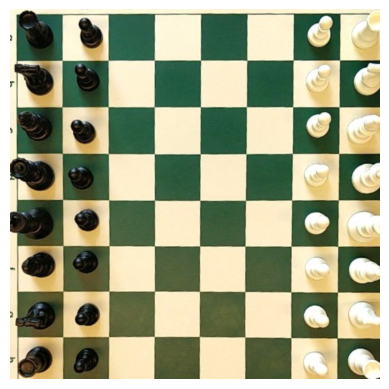

In [ ]:
size = 640
p = 10

dst = np.array(
    [[p, p], [size + p - 1, p], [size + p - 1, size + p - 1], [p, size + p - 1]],
    dtype="float32",
)

M = cv2.getPerspectiveTransform(board, dst)
warped = cv2.warpPerspective(image, M, (size + 2 * p, size + 2 * p))
plt.imshow(warped)
plt.axis('off')
plt.show()